For plotting nicely, so that my ADHD doesnt get triggered, I import this

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

Next is to import the cam, fs and slm objects

In [2]:
from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM

# Paths

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)



# Initialize hardware ONCE in this notebook


slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)

cal_file = r"c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5"

loaded = fs.load_calibration(
    "fourier",
    file_path=cal_file
)

print("Loaded:", loaded)
print("Current calibrations:", fs.calibrations.keys())

print("Current calibrations:")
print(fs.calibrations.keys())


# ------------------------------------------------------------
# Load the measured correction from disk
#
# This only creates a NumPy array called wavefront_phase.
# It does NOT activate the correction.
# ------------------------------------------------------------

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)


# ------------------------------------------------------------
# Inspect our starting state
# ------------------------------------------------------------

print("SLM shape:", slm.shape)
print("Camera shape:", cam.shape)

print("\nLoaded correction:")
print(" shape :", wavefront_phase.shape)
print(" finite:", np.all(np.isfinite(wavefront_phase)))
print(" min   :", wavefront_phase.min())
print(" max   :", wavefront_phase.max())

print("\nCurrent slm.source keys:")
print(slm.source.keys())

print("\nGlobal default slm.phase_correct:")
print(slm.phase_correct)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
Loaded: c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5
Current calibrations: dict_keys(['fourier'])
Current calibrations:
dict_keys(['fourier'])
SLM shape: (1200, 1920)
Camera shape: (3672, 5496)

Loaded correction:
 shape : (1200, 1920)
 finite: True
 min   : 0.0
 max   : 6.2831762207757835

Current slm.source keys:
dict_keys([])

Global default slm.phase_correct:
True


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


In [3]:
slm.phase_correct = False

print("phase_correct:", slm.phase_correct)
print("source:", slm.source.keys())

phase_correct: False
source: dict_keys([])


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameraslms.py:2574: UserWarning: The requested calibration point(s) are close to the expected positions of the field diffractive orders. Consider moving calibration regions further away.
  warnings.warn(


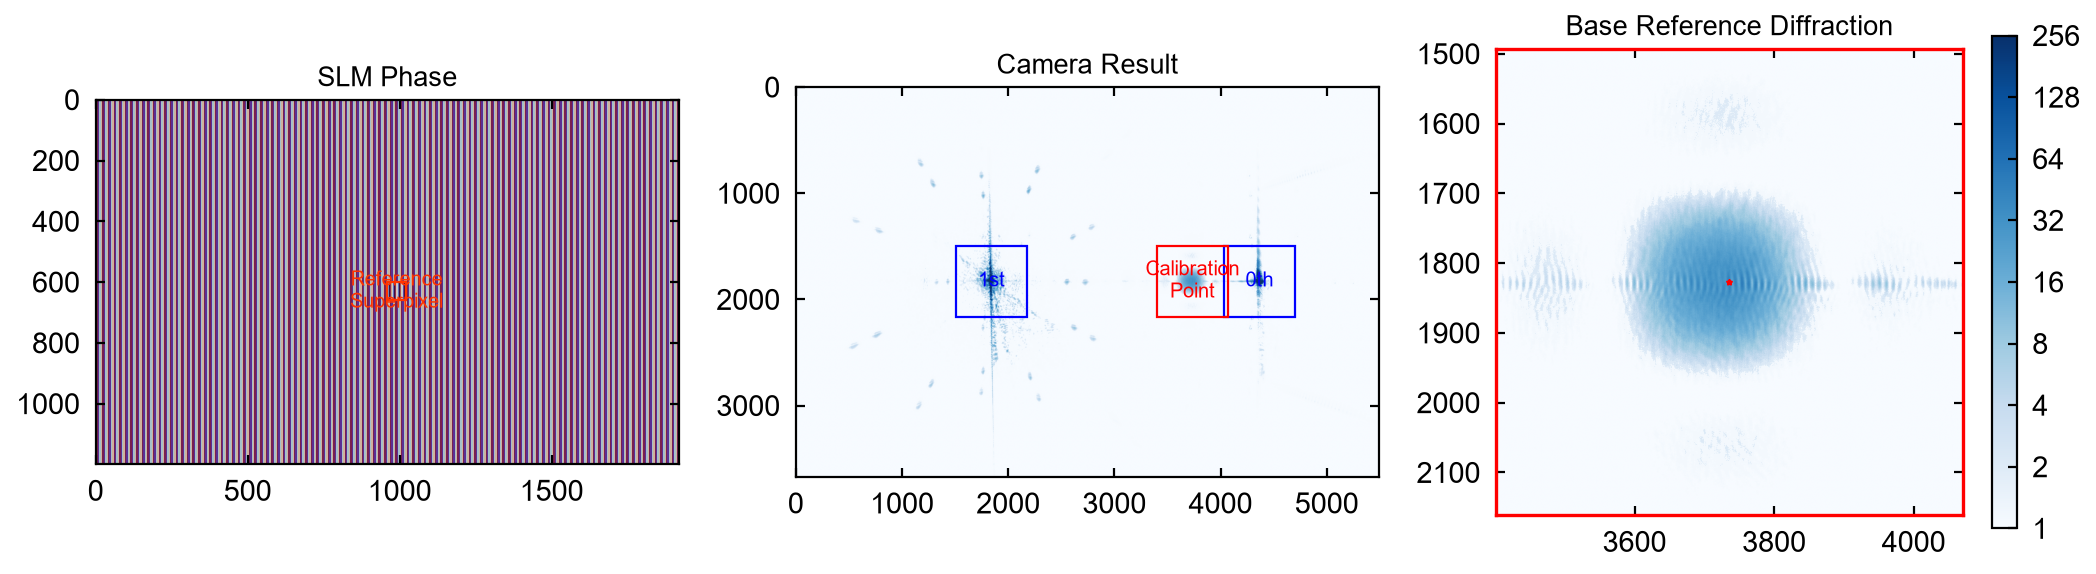

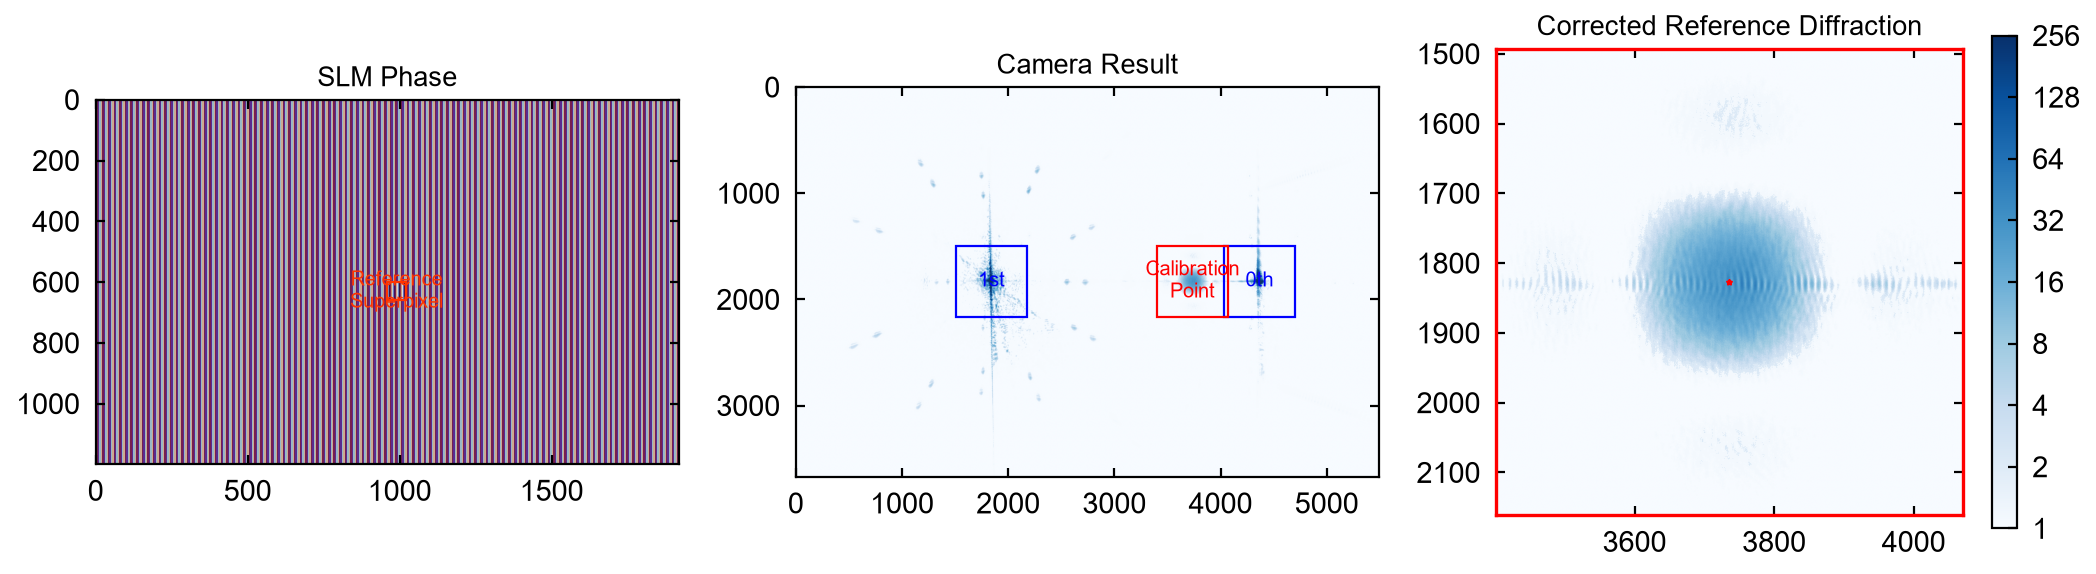

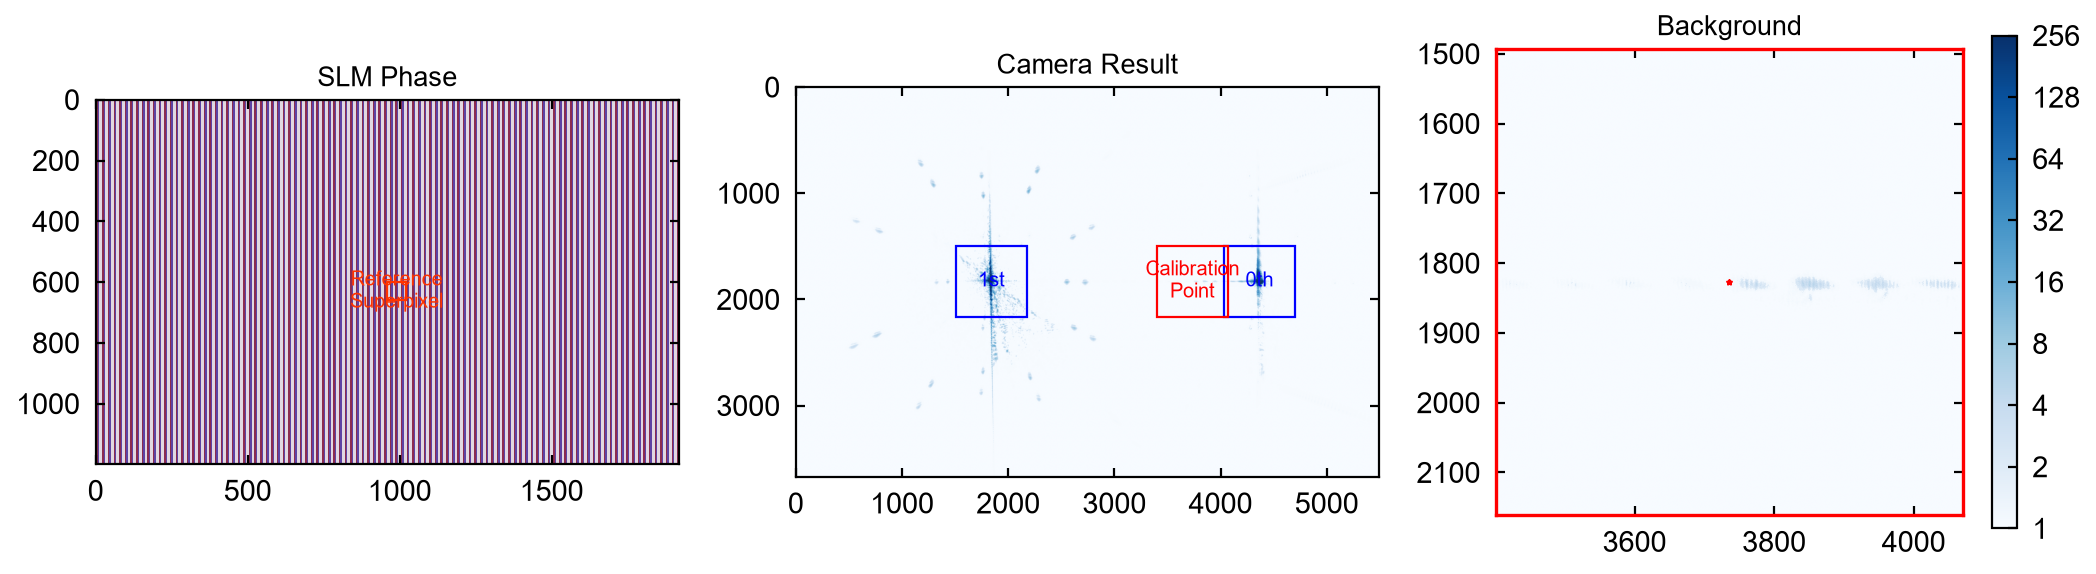

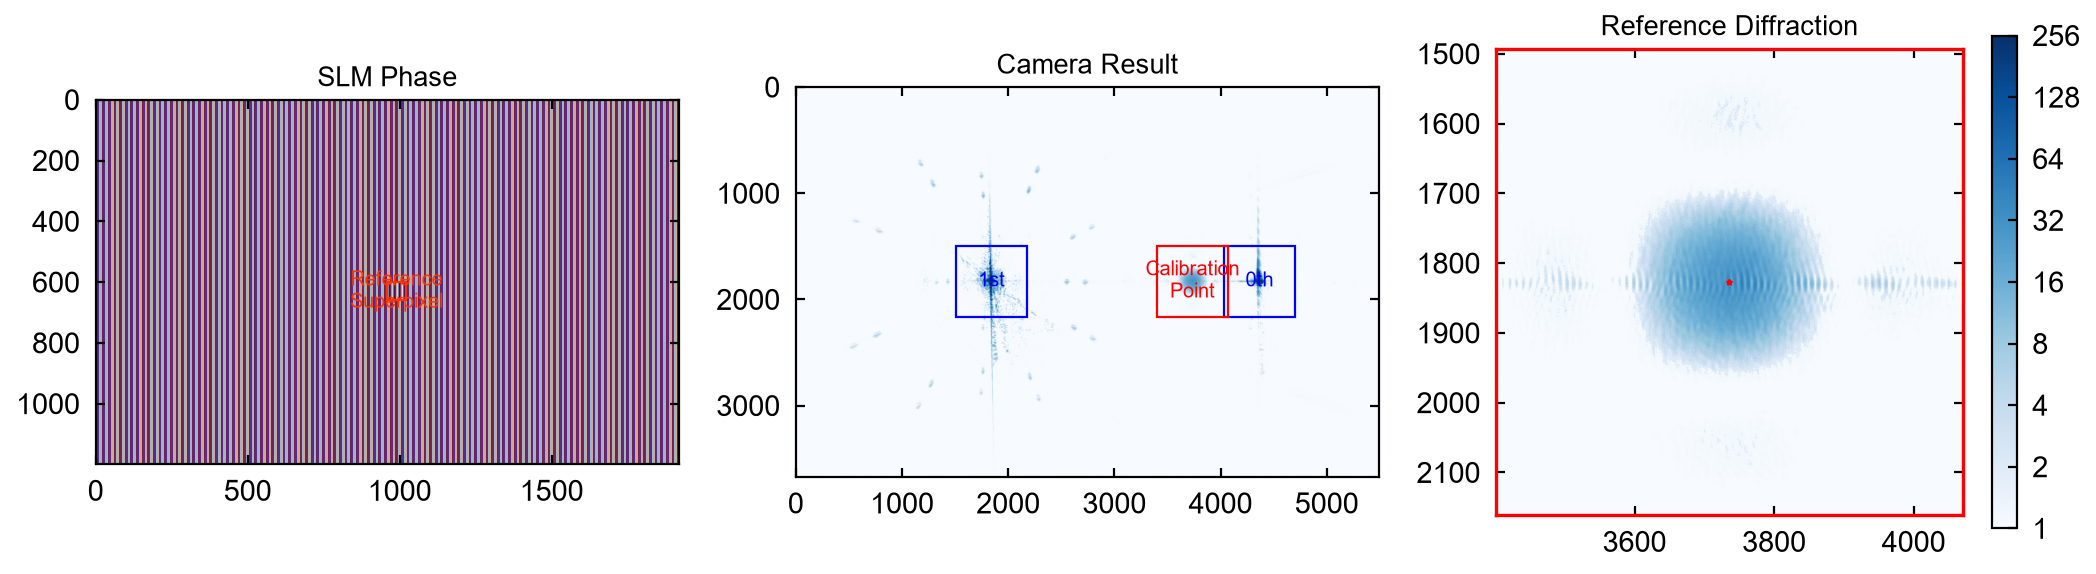

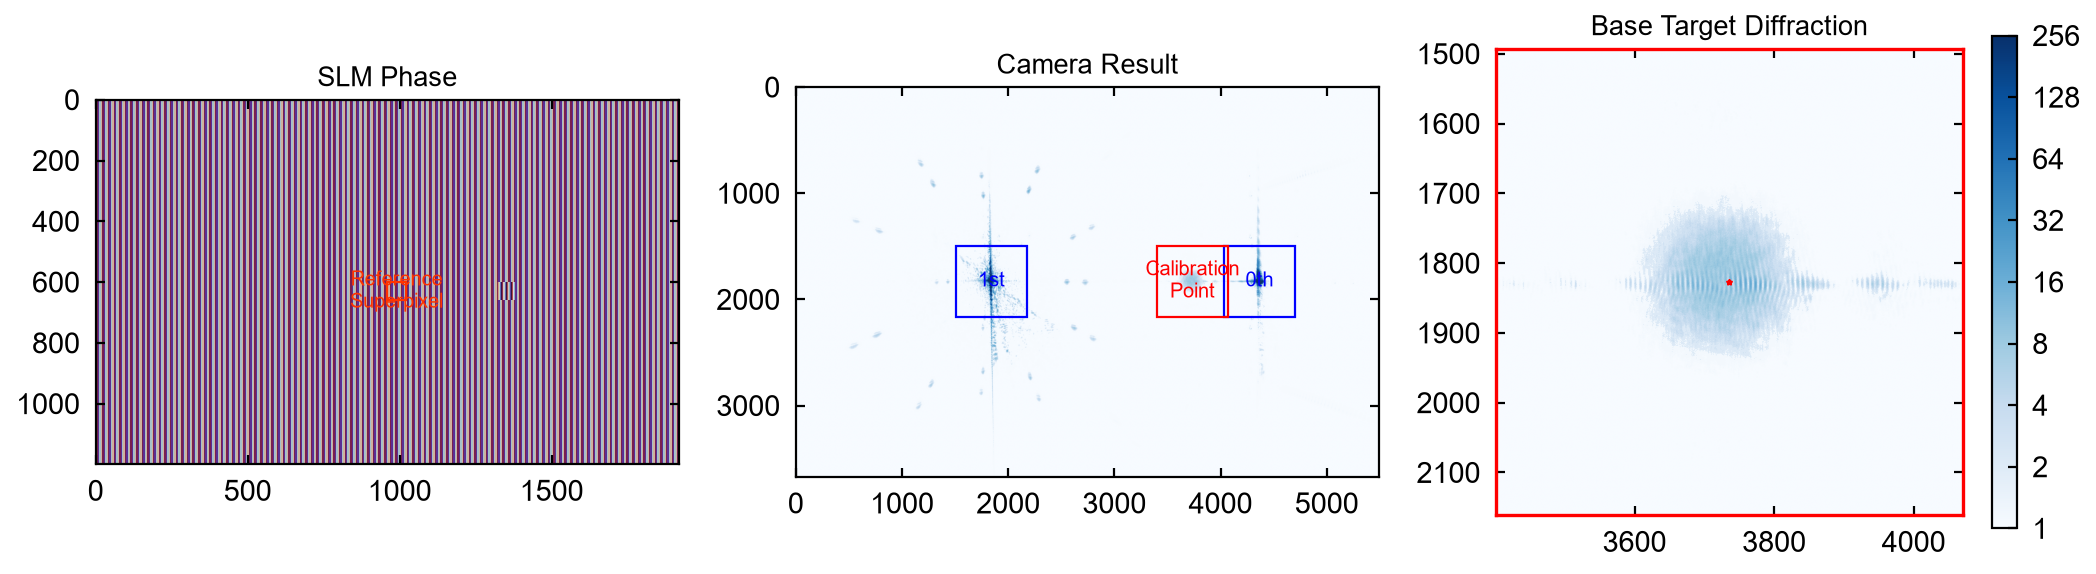

In [4]:
test = fs.wavefront_calibrate_superpixel(
    calibration_points=(3736, 1827),
    superpixel_size=60,
    reference_superpixels=None,
    test_index=5,
    field_point=(0.25, 0),
    field_point_units="freq",
    phase_steps=None,          # amplitude only
    fresh_calibration=True,
    measure_background=True,
    corrected_amplitude=False,
    plot=2
)

In [15]:
amp_cal = fs.wavefront_calibrate_superpixel(
    calibration_points=(3736, 1827),

    superpixel_size=60,
    reference_superpixels=None,

    field_point=(0.25, 0),
    field_point_units="freq",

    phase_steps=None,           # amplitude measurement only
    fresh_calibration=True,
    measure_background=True,
    corrected_amplitude=False,

    plot=0
)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameraslms.py:1373: UserWarning: The wavefront calibration is newer (2026-09-09 18:36:47.772157) than the Fourier calibration (2026-09-03 15:03:12.693725). The Fourier calibration may be stale.
  warnings.warn(
c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameraslms.py:2574: UserWarning: The requested calibration point(s) are close to the expected positions of the field diffractive orders. Consider moving calibration regions further away.
  warnings.warn(


calibration:   0%|          | 0/639 [00:00<?, ?it/s]

In [16]:
print(fs.calibrations.keys())

dict_keys(['fourier', 'wavefront_superpixel'])


In [17]:
SAVE_DIR = r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"

saved_path = fs.save_calibration(
    "wavefront_superpixel",
    path=SAVE_DIR,
    name="YDFC_beam_VERTICAL_CLIPPED_superpixel_60px_new"
)

print("Saved to:")
print(saved_path)

Saved to:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_beam_VERTICAL_CLIPPED_superpixel_60px_new_00000.h5


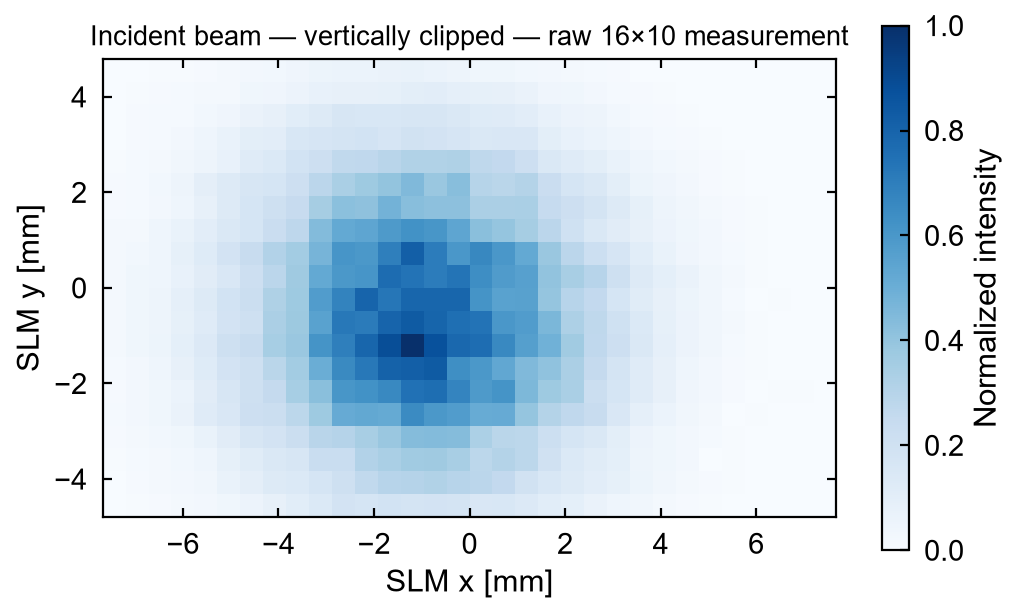

Shape: (20, 32)
[[0.003 0.005 0.011 0.019 0.024 0.037 0.056 0.08  0.106 0.139 0.181 0.17
  0.184 0.176 0.18  0.179 0.149 0.153 0.135 0.106 0.092 0.066 0.046 0.032
  0.021 0.009 0.005 0.003 0.    0.    0.    0.   ]
 [0.004 0.009 0.02  0.024 0.035 0.068 0.095 0.13  0.138 0.171 0.21  0.263
  0.294 0.303 0.316 0.294 0.284 0.261 0.195 0.155 0.129 0.102 0.082 0.055
  0.033 0.019 0.011 0.005 0.002 0.001 0.001 0.   ]
 [0.007 0.012 0.023 0.028 0.045 0.083 0.116 0.147 0.16  0.231 0.234 0.312
  0.339 0.366 0.369 0.342 0.28  0.305 0.28  0.198 0.14  0.115 0.091 0.05
  0.038 0.024 0.    0.006 0.003 0.001 0.    0.001]
 [0.009 0.02  0.03  0.037 0.07  0.112 0.163 0.183 0.222 0.289 0.304 0.342
  0.386 0.434 0.441 0.435 0.33  0.289 0.28  0.217 0.169 0.148 0.1   0.055
  0.037 0.024 0.012 0.004 0.002 0.001 0.    0.001]
 [0.012 0.025 0.038 0.064 0.119 0.151 0.212 0.226 0.281 0.373 0.512 0.525
  0.519 0.65  0.596 0.575 0.511 0.515 0.396 0.306 0.268 0.238 0.149 0.086
  0.059 0.034 0.019 0.002 0.005 0.001 0.  

In [18]:
import numpy as np
import matplotlib.pyplot as plt

raw = fs.calibrations["wavefront_superpixel"]

P = raw["power"][0].astype(float).copy()
N = raw["normalization"][0].astype(float).copy()
B = raw["background"][0].astype(float).copy()

ny, nx = P.shape

# Reference superpixel
ref = int(raw["reference_superpixels"][0])
xr = ref % nx
yr = ref // nx

def replace_ref(a):
    vals = []
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue

            yy = yr + dy
            xx = xr + dx

            if 0 <= yy < ny and 0 <= xx < nx:
                vals.append(a[yy, xx])

    a[yr, xr] = np.mean(vals)

replace_ref(P)
replace_ref(N)
replace_ref(B)

# Background- and normalization-corrected intensity
I = (P - B) / (N - B)

I[~np.isfinite(I)] = 0
I[I < 0] = 0
I /= np.max(I)

# Physical SLM dimensions
pitch_mm = 0.008
width_mm  = 1920 * pitch_mm
height_mm = 1200 * pitch_mm

plt.figure(figsize=(10/1.5, 6/1.5))

im = plt.imshow(
    I,
    extent=[
        -width_mm/2, width_mm/2,
        -height_mm/2, height_mm/2
    ],
    origin="lower",
    interpolation="nearest",
    aspect="equal",
    vmin=0,
    vmax=1
)

plt.xlabel("SLM x [mm]")
plt.ylabel("SLM y [mm]")
plt.title("Incident beam — vertically clipped — raw 16×10 measurement")
plt.colorbar(im, label="Normalized intensity")

plt.tight_layout()
plt.show()

print("Shape:", I.shape)
print(np.round(I, 3))